# Extended IBTrACS creation
This notebook is used to create the minimal "extended ibtracs" catalogue.

In [1]:
# Setting the environment
import huracanpy
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
from shapely.geometry import Polygon, MultiPolygon, Point
import geopandas as gpd
from tqdm import tqdm
from haversine import haversine
import os

In [2]:
# Parameters
BASIN = "NA" 
UPDATE = False # Set to True to update IBTrACS file to latest version
#PROJ = ccrs.AlbersEqualArea(central_longitude=-45, central_latitude=33,) # Projection used for plots
#sns.set_palette("colorblind")

## 1. Load source data

In [3]:
# Download latest IBTrACS NA file (or not)
if UPDATE:
    # Download latest NA dataset
    ib = huracanpy.load(source = "ibtracs", ibtracs_subset="NA",)
    # Remove columns that are all NaNs
    for var in ib.variables.keys():
        if ib[var].isnull().all():
            ib = ib.drop_vars(var)
    # Rename track id
    ib = ib.rename({"sid":"track_id"})
    # Save file
    ib.hrcn.save("../input/ibtracs.csv")
else: # Load from previously saved file
    ib = huracanpy.load("../input/ibtracs.csv")
# Convert winds to m/s
ib = ib.assign(wind10 = ib.usa_wind * 0.514444)

/Users/bourdin/Softs/huracanpy/huracanpy/_data/_csv.py:88: DtypeWarning: Columns (43,52) have mixed types. Specify dtype option on import or set low_memory=False.
  tracks = load_function(filename, **kwargs)


In [4]:
tracks = {} # Dict to store all tracks

In [5]:
# Load SyCLoPS data
tracks["SyCLoPS-ERA5"] = huracanpy.load("../input/ERA5_SyCLoPS_classified.parquet", baselon = -180).rename({"tid":"track_id"})
tracks["SyCLoPS-ERA5"] = tracks["SyCLoPS-ERA5"].assign(track_id = tracks["SyCLoPS-ERA5"].track_id.astype(str)).rename({"mslp":"pres", "ws":"wind10"})

In [6]:
# Load TRACK data: Full tracks
for ds in tqdm(["ERA5", "JRA3Q", "ERA20C","ECMWF-OP-AN"]):
    tracks["TRACK-"+ds] = xr.open_dataset("../input/"+ds+"_TRACK_NATL_all.nc",).rename({"psl":"pres",})
    if "wind10m" in list(tracks["TRACK-"+ds].variables.keys()):
        tracks["TRACK-"+ds] = tracks["TRACK-"+ds].rename({"wind10m":"wind10"})

100%|████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.41s/it]


In [7]:
# Convert pressures to hPa
for ds in tracks:
    if tracks[ds].pres.mean() > 10000: # Identify if pressure is in Pa
        tracks[ds] = tracks[ds].assign(pres = tracks[ds].pres / 100) # Convert to hPa

In [8]:
# Highlight duration of each input dataset
for ds in tracks: 
    Y = tracks[ds].time.dt.year.values
    print(ds, ':', Y.min(), 'to', Y.max())

SyCLoPS-ERA5 : 1979 to 2022
TRACK-ERA5 : 1940 to 2022
TRACK-JRA3Q : 1948 to 2024
TRACK-ERA20C : 1901 to 2010
TRACK-ECMWF-OP-AN : 2006 to 2024


## 2. Matching

In [9]:
# Safekeep old information
tracks_save = tracks.copy()
for ds in tracks: 
    tracks[ds]["track_id_old"] = tracks[ds]["track_id"].copy()
# Restore
tracks = tracks_save.copy()

In [10]:
# Step 1: For each dataset, perform individual matching and treat duplicates
MIN_OVERLAP = 3
MAX_DIST = 400

for ds in tqdm(tracks):
    ## Step 1a: Match the dataset with ibtracs
    M = huracanpy.assess.match([ib, tracks[ds]], ["ib", ds], min_overlap = MIN_OVERLAP, max_dist = MAX_DIST, 
                              tracks1_is_ref = True,   # Treat the duplicates where one reanalysis tracks has several corresponding IBTrACS:
                                                       # Keep the couple with longest overlap
                              )    
    ## Step 1b: Treat the duplicates where several RA tracks correspond to 1 obs.: Merge them together
    ### Merge with M to subset matched trackss and assign matching distance
    tracks[ds] = tracks[ds].to_dataframe().merge(M.rename(columns = {"id_"+ds:"track_id"})[["track_id", "dist"]])
    ### Update merged ids
    new_ids = M.groupby('id_ib')["id_"+ds].apply(lambda s: '+'.join(s))
    replace = M.join(new_ids, on = "id_ib", lsuffix = "_old", rsuffix = "_new")[["id_"+ds+"_old", "id_"+ds+"_new"]]
    tracks[ds]["track_id"] = tracks[ds]["track_id"].replace(replace.set_index("id_"+ds+"_old")["id_"+ds+"_new"].to_dict())
    ### When several times are for one track_id: keep the one belonging to the closest tracks to IBTrACS
    tracks[ds] = tracks[ds].sort_values("dist").groupby(["track_id", "time"]).first().reset_index()
    ### Retransform into xarray
    tracks[ds] = tracks[ds].to_xarray().rename({"index":"record"})

100%|████████████████████████████████████████████████████████████████████| 5/5 [00:25<00:00,  5.12s/it]


In [11]:
# Redo the matching now that the tracks have been merged
M = huracanpy.assess.match([ib, ib, *tracks.values()], ["ib", "ib2", *tracks.keys()], 
                           min_overlap = MIN_OVERLAP, max_dist = MAX_DIST, 
                           tracks1_is_ref = True,
                          ).drop(columns = "id_ib2").drop_duplicates()
# Note : The double ib is a trick to make sure all tracks from IBTrACS are included since they all match with themselves
# Remove matches where IBTrACS is not involved: IBTrACS is considered ground truth for whether a track was tropical
M  = M[~(M.id_ib.isna())]

## 3. Gather all the information in a catalogue

In [12]:
tracks_matched = []
for id_ib in tqdm(M.id_ib.unique()): # Loop over rows of M
    # Matches
    m = M[M.id_ib == id_ib]
    
    # Storm attributes
    name = ib.hrcn.sel_id(id_ib).name[0].values

    # Merge all data about the track in one dataset
    track = ib[["track_id", "lon", "lat", "time","usa_pres","wind10"]].hrcn.sel_id(id_ib).set_coords("time").swap_dims({"record":"time"}
                                                    ).assign(dataset = "IBTrACS").set_coords("dataset"
                                                    ).rename({"usa_pres":"pres",})
    for ds in tracks:
        ds_id = getattr(m, "id_"+ds).values[0] # ID in the given dataset
        tid = tracks[ds].hrcn.sel_id(ds_id).set_coords("time").swap_dims({"record":"time"}
                                                                        ).reset_coords()[["track_id", "lon", "lat", "pres", "wind10"]
                ].assign(dataset = ds).set_coords("dataset")
        track = xr.concat([track, tid], dim = "dataset")
    
    # Save into tracks
    tracks_matched.append(track.swap_dims({"time":"record"}).rename({"track_id":"track_id_dataset"}).assign(track_id = id_ib, name = name))
    
# Concatenate all tracks in a new dataset
tracks_matched = xr.concat(tracks_matched, dim = "record")

100%|██████████████████████████████████████████████████████████████| 2283/2283 [00:35<00:00, 63.94it/s]


In [13]:
tracks_matched

<xarray.Dataset> Size: 67MB
Dimensions:           (dataset: 6, record: 188964)
Coordinates:
    time              (record) datetime64[ns] 2MB 1901-06-25T12:00:00 ... 202...
  * dataset           (dataset) <U17 408B 'IBTrACS' ... 'TRACK-ECMWF-OP-AN'
Dimensions without coordinates: record
Data variables:
    track_id_dataset  (dataset, record) object 9MB nan nan nan ... nan nan nan
    lon               (dataset, record) float64 9MB nan nan nan ... nan nan nan
    lat               (dataset, record) float64 9MB nan nan nan ... nan nan nan
    pres              (dataset, record) float64 9MB nan nan nan ... nan nan nan
    wind10            (dataset, record) float64 9MB nan nan nan ... nan nan nan
    track_id          (record) <U13 10MB '1901183N09306' ... '2024317N17284'
    name              (record) <U13 10MB 'UNNAMED' 'UNNAMED' ... 'SARA' 'SARA'

## 4. Quality control
We check that the distance between the IBTrACS record and the corresponding (re)analysis tracks are of the order of magnitude of the cell size of each dataset.

In [14]:
def haversine4(a,b,c,d):
    return haversine((a,b),(c,d))
haversine_vec = np.vectorize(haversine4)

In [15]:
tracks_matched["dist2ib"] = xr.apply_ufunc(haversine_vec, 
                                           tracks_matched.sel(dataset = "IBTrACS").lat, tracks_matched.sel(dataset = "IBTrACS").lon, 
                                           tracks_matched.lat, tracks_matched.lon)

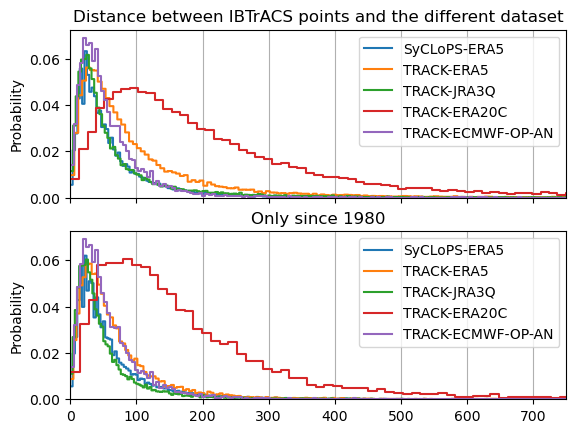

In [16]:
fig, axs = plt.subplots(2, sharex = True)
for ds in tracks:
    sns.histplot(data = tracks_matched.sel(dataset = ds)["dist2ib"], 
                 fill = False, element = "step", stat = "probability", label = ds, ax= axs[0])
axs[0].legend()
axs[0].set_title("Distance between IBTrACS points and the different dataset")
axs[0].grid(axis = 'x')

for ds in tracks:
    sns.histplot(data = tracks_matched.where(tracks_matched.time.dt.year >= 1980).sel(dataset = ds)["dist2ib"], 
                 fill = False, element = "step", stat = "probability", label = ds, ax= axs[1])
axs[1].legend()
axs[1].set_xlim(0,750)
axs[1].set_title("Only since 1980")
axs[1].grid(axis = 'x')

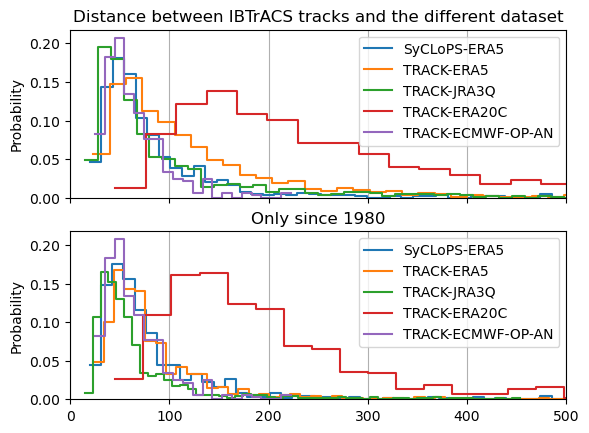

In [17]:
fig, axs = plt.subplots(2, sharex = True)
sns.set_palette("Set1")
for ds in tracks:
    sns.histplot(data = tracks_matched.sel(dataset = ds)["dist2ib"].groupby(tracks_matched.track_id).mean(), 
                 fill = False, element = "step", stat = "probability", label = ds, ax= axs[0])
axs[0].legend()
axs[0].set_title("Distance between IBTrACS tracks and the different dataset")
axs[0].grid(axis = 'x')

for ds in tracks:
    t1980 = tracks_matched.where(tracks_matched.time.dt.year >= 1980)
    sns.histplot(data = t1980.sel(dataset = ds)["dist2ib"].groupby(t1980.track_id).mean(), 
                 fill = False, element = "step", stat = "probability", label = ds, ax= axs[1])
axs[1].legend()
axs[1].set_xlim(0,500)
axs[1].set_title("Only since 1980")
axs[1].grid(axis = 'x')

## 5. Save

In [18]:
# Save to netcdf
tracks_matched[["track_id","lon", "lat", "name", "pres", "wind10"]].reset_coords().to_netcdf("../files/extended_ibtracs.nc")